<a href="https://colab.research.google.com/github/vibeshvidya/Advanced-AI-ML/blob/main/Loan_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROBLEM STATEMENT

Dream Housing Finance company deals in all home loans. They have a presence across all urban, semi-urban and rural areas. Customers first apply for a home loan after that company validates the customer’s eligibility for a loan. The company wants to automate the loan eligibility process (real-time) based on customer detail provided while filling out the online application form. These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History, and others. To automate this process, they have given a problem to identify the customer segments, that are eligible for loan amounts so that they can specifically target these customers.

# SOLUTION

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
data = pd.read_csv('/content/drive/MyDrive/train_loan.csv')

In [14]:
df = data.copy()

In [15]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# DATA ANALYSIS

**Univariate Analysis**

Analysis of a single feature/column

In [16]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [17]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [18]:
num_cols = [column for column in df.columns if df[column].dtypes != 'O']

In [19]:
df['Gender'].dtypes

dtype('O')

In [20]:
num_cols_chk = [column for column in df.columns if df[column].dtype != 'O']

In [21]:
num_cols_chk

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

In [22]:
num_cols

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

In [23]:
df[num_cols]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,NaN,360.0,1.0
1,4583,1508.0,128.0,360.0,1.0
2,3000,0.0,66.0,360.0,1.0
3,2583,2358.0,120.0,360.0,1.0
4,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0
610,4106,0.0,40.0,180.0,1.0
611,8072,240.0,253.0,360.0,1.0
612,7583,0.0,187.0,360.0,1.0


In [24]:
df['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [25]:
df['Dependents'].nunique()

4

In [26]:
df['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [27]:
df['Dependents'].replace('3+',3,inplace=True)

/tmp/ipykernel_10249/2408873931.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].replace('3+',3,inplace=True)


In [28]:
df['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
3,51


In [29]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [30]:
df[num_cols]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,NaN,360.0,1.0
1,4583,1508.0,128.0,360.0,1.0
2,3000,0.0,66.0,360.0,1.0
3,2583,2358.0,120.0,360.0,1.0
4,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0
610,4106,0.0,40.0,180.0,1.0
611,8072,240.0,253.0,360.0,1.0
612,7583,0.0,187.0,360.0,1.0


In [31]:
df.shape

(614, 13)

In [32]:
df['ApplicantIncome'].value_counts()

,count
ApplicantIncome,
2500,9
4583,6
6000,6
2600,6
5000,5
...,...
11000,1
3416,1
1907,1


In [33]:
df['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


In [34]:
df['ApplicantIncome'].nunique()

505

In [35]:
df['Loan_Amount_Term'].nunique()

10

In [36]:
df['Credit_History'].nunique()

2

Univariate Analysis of Continuous Numerical Columns

In [37]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


/tmp/ipykernel_10249/2349853404.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ApplicantIncome'])


<Axes: xlabel='ApplicantIncome', ylabel='Density'>

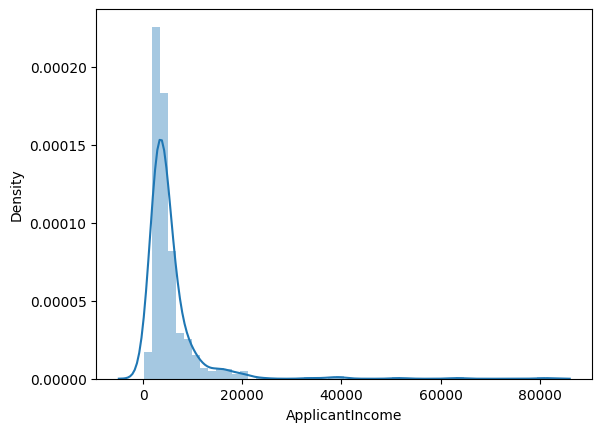

In [38]:
sns.distplot(df['ApplicantIncome'])

<Axes: ylabel='ApplicantIncome'>

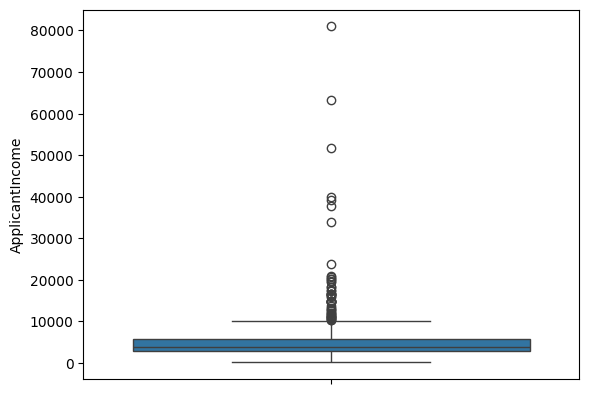

In [39]:
sns.boxplot(df['ApplicantIncome'])

We have seen there is extremen outliers in ApplicantIncome, so not suggested to use Mean for Missing Value Handling

/tmp/ipykernel_10249/2149142820.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CoapplicantIncome'])


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

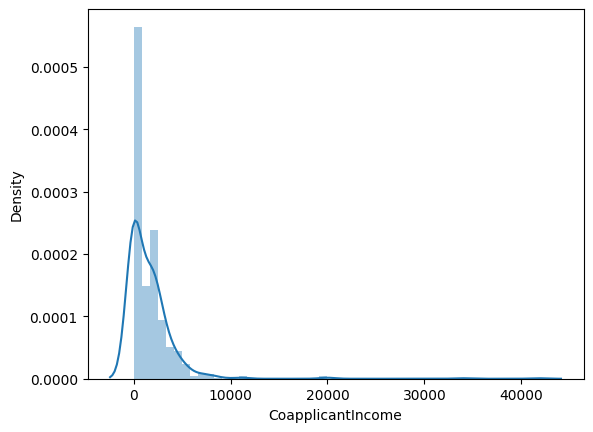

In [40]:
sns.distplot(df['CoapplicantIncome'])

<Axes: ylabel='CoapplicantIncome'>

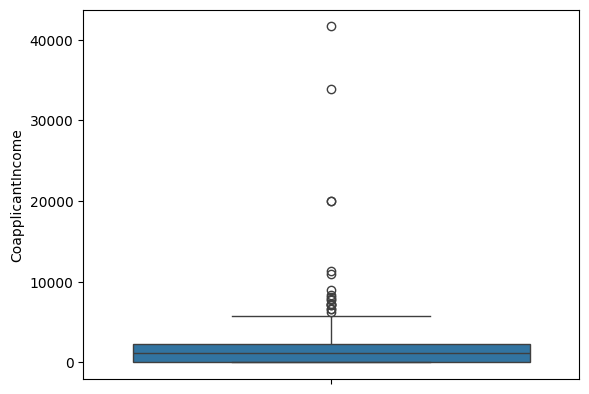

In [41]:
sns.boxplot(df['CoapplicantIncome'])

<Axes: ylabel='LoanAmount'>

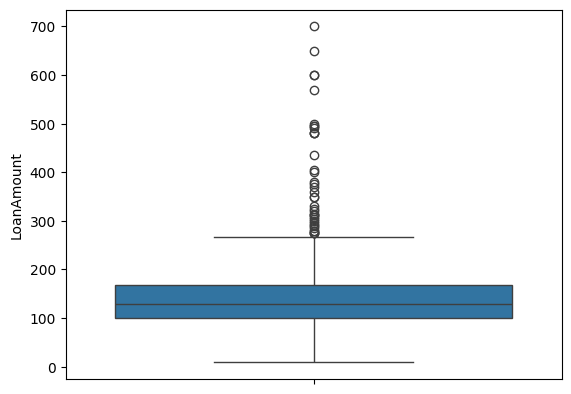

In [42]:
sns.boxplot(df['LoanAmount'])

Univariate Analysis of Discrete Numerical Columns

Cardinality check of the columns

<Axes: xlabel='Dependents', ylabel='count'>

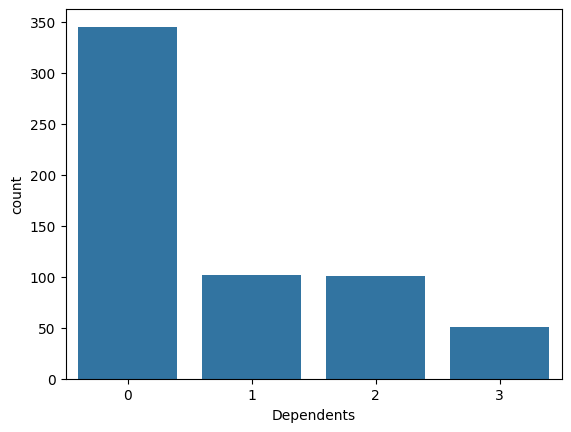

In [43]:
sns.countplot(x='Dependents', data=df)

<Axes: xlabel='Loan_Amount_Term', ylabel='count'>

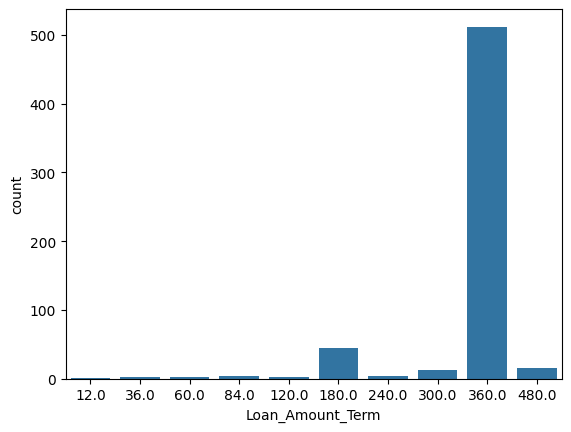

In [44]:
sns.countplot(x='Loan_Amount_Term', data=df)

<Axes: xlabel='Credit_History', ylabel='count'>

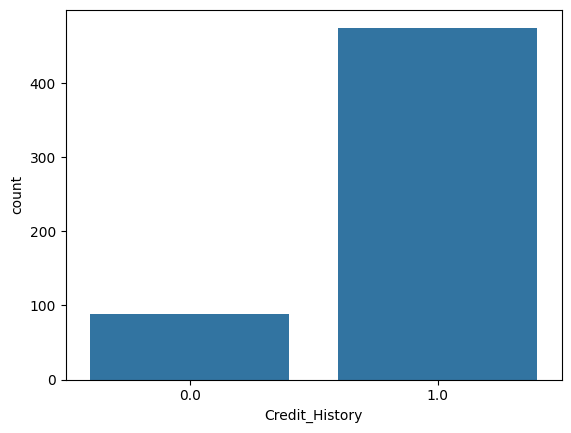

In [45]:
sns.countplot(x='Credit_History', data=df)

Univariate Analysis of Categorical Columns

In [46]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

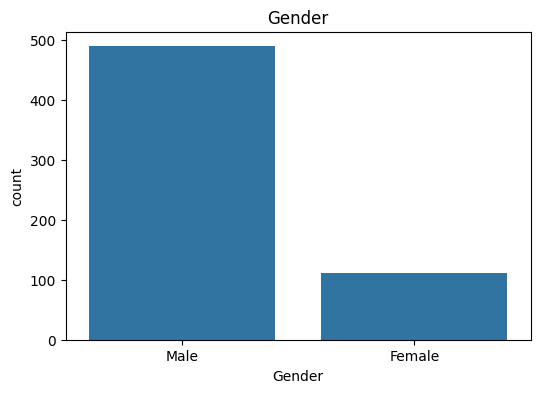

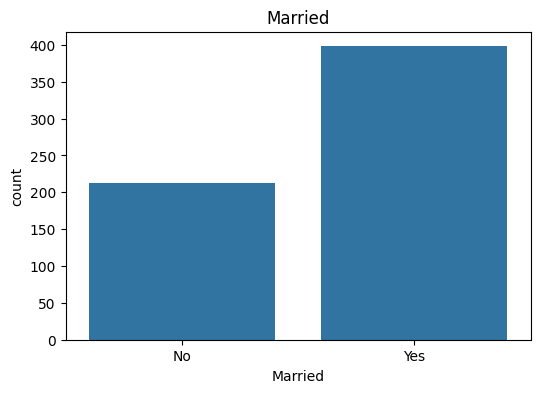

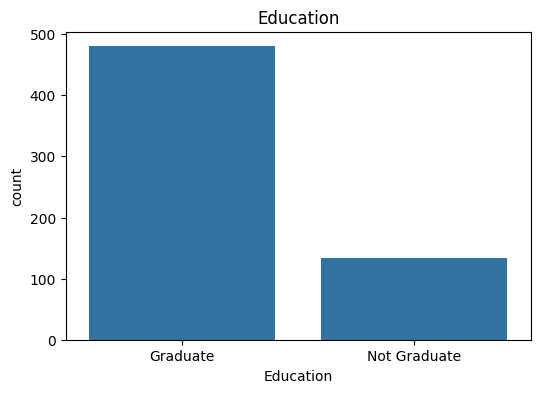

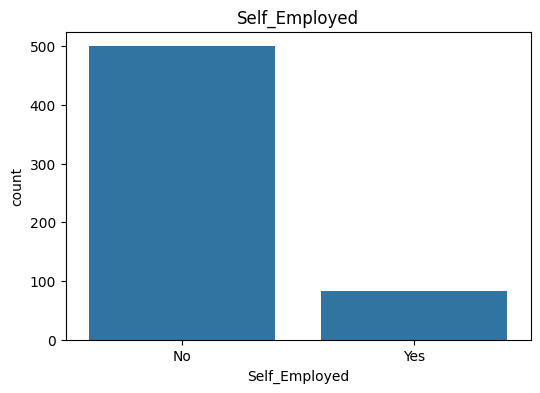

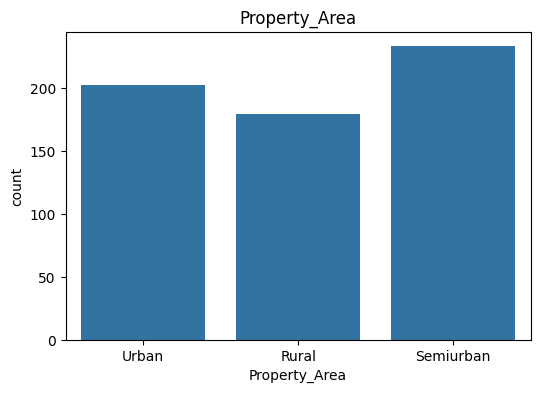

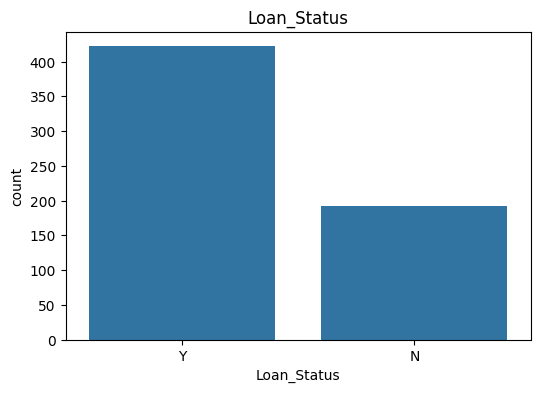

In [47]:
cat_cols = ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']

for columns in cat_cols:
  plt.figure(figsize=(6,4))
  sns.countplot(x=columns, data=df)
  plt.title(columns)
  plt.show()

**Bi-Variate Analysis**

In [48]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<Axes: xlabel='Gender', ylabel='count'>

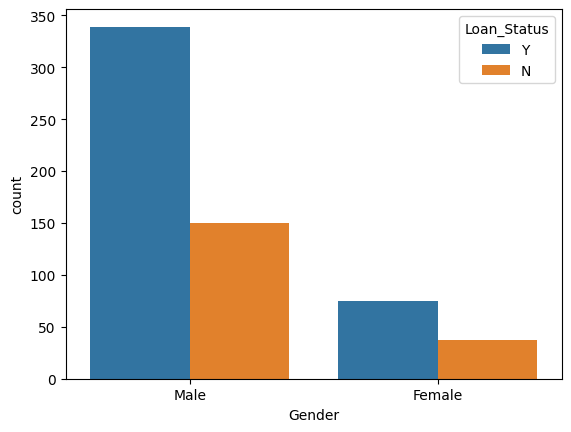

In [49]:
sns.countplot(x='Gender', hue='Loan_Status', data=df)

<Axes: xlabel='Gender', ylabel='Percent'>

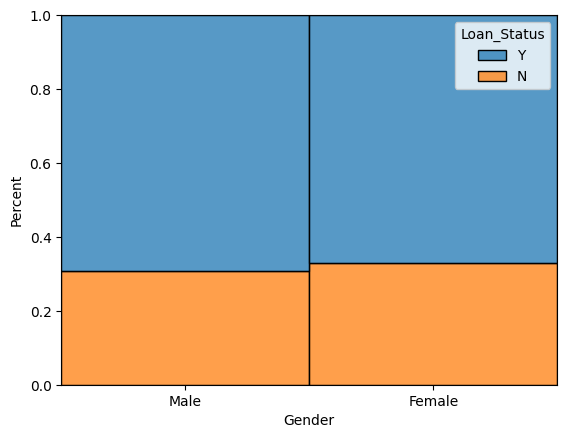

In [50]:
sns.histplot(data=df, x='Gender', hue='Loan_Status', multiple='fill', stat='percent')

In [51]:
pd.crosstab(df['Gender'], df['Loan_Status'], normalize='index')*100

Loan_Status,N,Y
Gender,,
Female,33.035714,66.964286
Male,30.674847,69.325153


In [52]:
df['Gender'].value_counts()

,count
Gender,
Male,489
Female,112


<Axes: xlabel='Gender'>

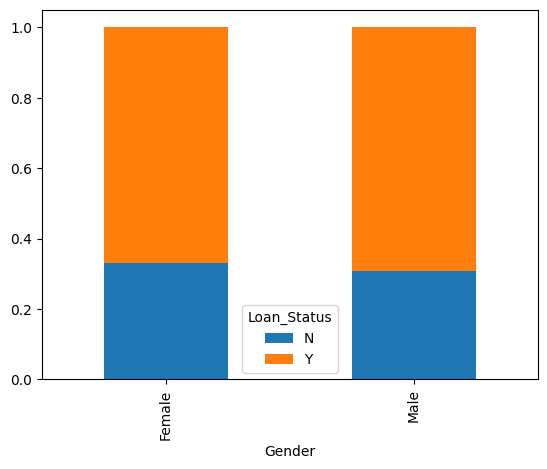

In [53]:
pd.crosstab(df['Gender'], df['Loan_Status'], normalize='index').plot(kind='bar', stacked=True)

<Axes: xlabel='Married'>

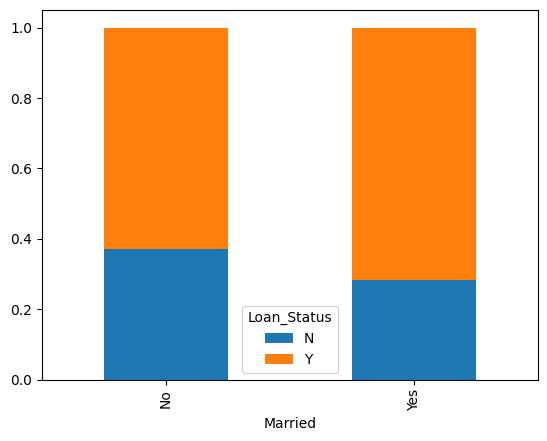

In [54]:
pd.crosstab(df['Married'], df['Loan_Status'], normalize='index').plot(kind='bar', stacked=True)

In [55]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [56]:
df.groupby('Married')['CoapplicantIncome'].mean()

,CoapplicantIncome
Married,
No,1316.558685
Yes,1794.632965


In [57]:
df.groupby('Married')['ApplicantIncome'].mean()

,ApplicantIncome
Married,
No,4970.384977
Yes,5629.173367


<Axes: xlabel='Education'>

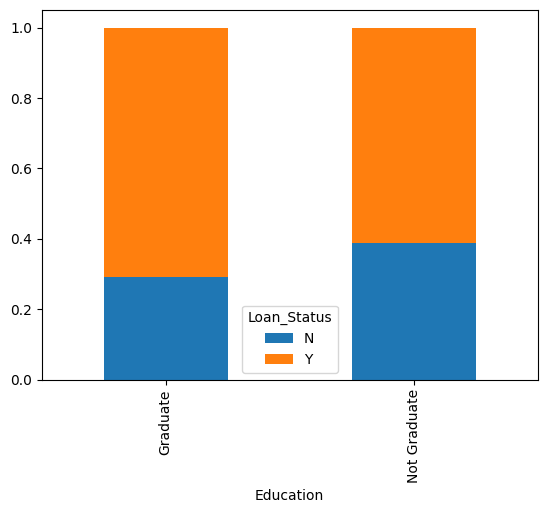

In [58]:
pd.crosstab(df['Education'], df['Loan_Status'], normalize='index').plot(kind='bar', stacked=True)

In [59]:
pd.crosstab(df['Education'], df['Loan_Status'], normalize='index')*100

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


<Axes: xlabel='Self_Employed'>

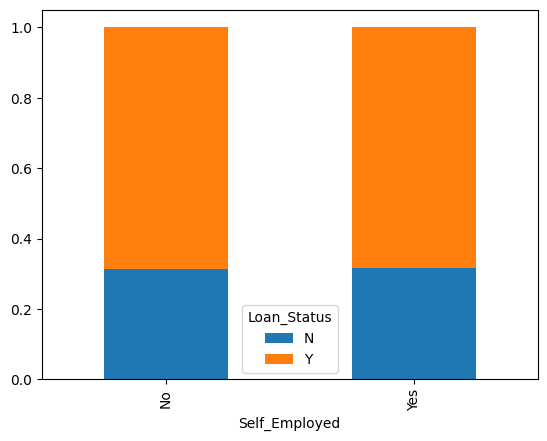

In [60]:
pd.crosstab(df['Self_Employed'], df['Loan_Status'], normalize='index').plot(kind='bar', stacked=True)

In [61]:
pd.crosstab(df['Self_Employed'], df['Loan_Status'], normalize='index')*100

Loan_Status,N,Y
Self_Employed,,
No,31.400000,68.600000
Yes,31.707317,68.292683


**Multi-Variate Analysis**

In [62]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<Axes: xlabel='Gender', ylabel='Count'>

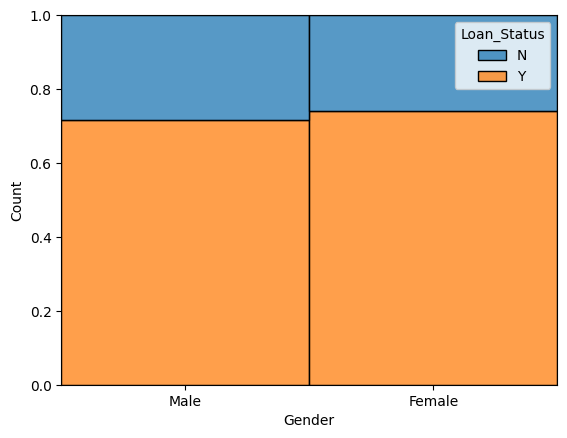

In [63]:
sns.histplot(data=df[df['Married']=='Yes'], x='Gender',hue='Loan_Status', multiple='fill')

<Axes: xlabel='Gender', ylabel='Count'>

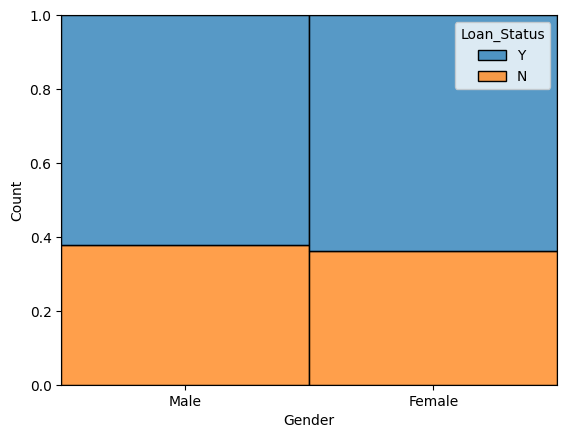

In [64]:
sns.histplot(data=df[df['Married']=='No'], x='Gender',hue='Loan_Status', multiple='fill')

<Axes: xlabel='Education', ylabel='Count'>

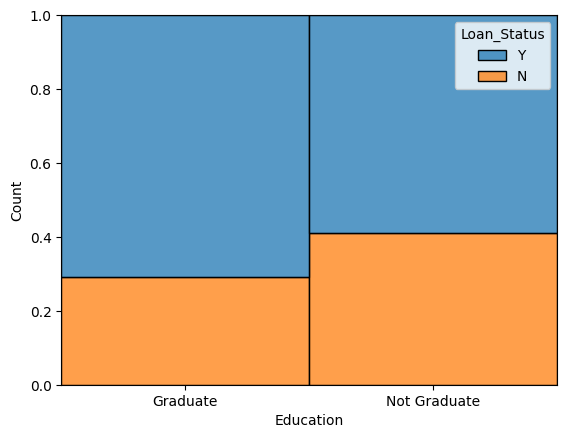

In [65]:
sns.histplot(data=df[df['Self_Employed']=='Yes'], x='Education',hue='Loan_Status', multiple='fill')

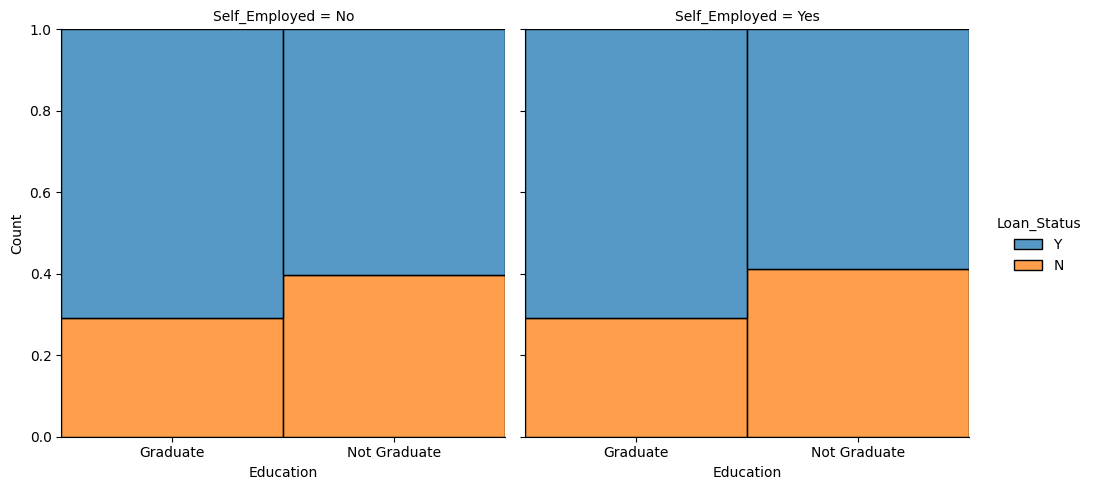

In [66]:
sns.displot(data=df, x='Education',hue='Loan_Status', col='Self_Employed', multiple='fill')

what is observation?

In [67]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# FEATURE ENGINEERING

In [68]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [69]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [70]:
df['Dependents'].unique()

array(['0', '1', '2', 3, nan], dtype=object)

In [71]:
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)

/tmp/ipykernel_10249/2656529728.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)


In [72]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [73]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [74]:
df['Dependents'] = df['Dependents'].astype('int')

In [75]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,int64
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [76]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [77]:
df[df['Gender'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
126,LP001448,NaN,Yes,3,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y
171,LP001585,NaN,Yes,3,Graduate,No,51763,0.0,700.0,300.0,1.0,Urban,Y
188,LP001644,NaN,Yes,0,Graduate,Yes,674,5296.0,168.0,360.0,1.0,Rural,Y
314,LP002024,NaN,Yes,0,Graduate,No,2473,1843.0,159.0,360.0,1.0,Rural,N
334,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,Y
460,LP002478,NaN,Yes,0,Graduate,Yes,2083,4083.0,160.0,360.0,NaN,Semiurban,Y
467,LP002501,NaN,Yes,0,Graduate,No,16692,0.0,110.0,360.0,1.0,Semiurban,Y
477,LP002530,NaN,Yes,2,Graduate,No,2873,1872.0,132.0,360.0,0.0,Semiurban,N
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N


In [78]:
pd.crosstab(df['Dependents'],[df['Married'],df['Gender']],normalize="index")*100

Married            No                  Yes           
Gender         Female       Male    Female       Male
Dependents                                           
0           17.714286  31.714286  5.714286  44.857143
1           12.871287   9.900990  5.940594  71.287129
2            2.020202   6.060606  5.050505  86.868687
3            6.250000   6.250000  0.000000  87.500000

In [79]:
mode_gender_3D_Y = df.loc[(df['Married']=="Yes")&(df['Dependents']==3),"Gender"].mode()[0]

In [80]:
mode_gender_3D_Y

'Male'

In [81]:
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==3),"Gender"] = mode_gender_3D_Y

In [82]:
df[df['Gender'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
188,LP001644,NaN,Yes,0,Graduate,Yes,674,5296.0,168.0,360.0,1.0,Rural,Y
314,LP002024,NaN,Yes,0,Graduate,No,2473,1843.0,159.0,360.0,1.0,Rural,N
334,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,Y
460,LP002478,NaN,Yes,0,Graduate,Yes,2083,4083.0,160.0,360.0,NaN,Semiurban,Y
467,LP002501,NaN,Yes,0,Graduate,No,16692,0.0,110.0,360.0,1.0,Semiurban,Y
477,LP002530,NaN,Yes,2,Graduate,No,2873,1872.0,132.0,360.0,0.0,Semiurban,N
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N
576,LP002872,NaN,Yes,0,Graduate,No,3087,2210.0,136.0,360.0,0.0,Semiurban,N
588,LP002925,NaN,No,0,Graduate,No,4750,0.0,94.0,360.0,1.0,Semiurban,Y


In [83]:
mode_gender_2D_Y = df.loc[(df['Married']=="Yes")&(df['Dependents']==2),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==2),"Gender"] = mode_gender_2D_Y

mode_gender_1D_Y = df.loc[(df['Married']=="Yes")&(df['Dependents']==1),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==1),"Gender"] = mode_gender_1D_Y

mode_gender_0D_Y = df.loc[(df['Married']=="Yes")&(df['Dependents']==0),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==0),"Gender"] = mode_gender_0D_Y

In [84]:
df.isna().sum()

,0
Loan_ID,0
Gender,3
Married,3
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [85]:
df[df['Gender'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N
588,LP002925,NaN,No,0,Graduate,No,4750,0.0,94.0,360.0,1.0,Semiurban,Y
592,LP002933,NaN,No,3,Graduate,Yes,9357,0.0,292.0,360.0,1.0,Semiurban,Y


In [86]:
mode_gender_3D_N = df.loc[(df['Married']=="No")&(df['Dependents']==3),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='No')&(df['Dependents']==3),"Gender"] = mode_gender_3D_N

mode_gender_0D_N = df.loc[(df['Married']=="No")&(df['Dependents']==0),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='No')&(df['Dependents']==0),"Gender"] = mode_gender_0D_N

In [87]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,3
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [88]:
df[df['Married'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
104,LP001357,Male,NaN,0,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y
228,LP001760,Male,NaN,0,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,Y
435,LP002393,Female,NaN,0,Graduate,No,10047,0.0,NaN,240.0,1.0,Semiurban,Y


In [89]:
df.loc[104,'Married'] = 'Yes'
df.loc[228,'Married'] = 'No'
df.loc[435,'Married'] = 'No'

In [90]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [91]:
df[df['Self_Employed'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
11,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
19,LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
24,LP001052,Male,Yes,1,Graduate,NaN,3717,2925.0,151.0,360.0,NaN,Semiurban,N
29,LP001087,Female,No,2,Graduate,NaN,3750,2083.0,120.0,360.0,1.0,Semiurban,Y
30,LP001091,Male,Yes,1,Graduate,NaN,4166,3369.0,201.0,360.0,NaN,Urban,N
95,LP001326,Male,No,0,Graduate,NaN,6782,0.0,NaN,360.0,NaN,Urban,N
107,LP001370,Male,No,0,Not Graduate,NaN,7333,0.0,120.0,360.0,1.0,Rural,N
111,LP001387,Female,Yes,0,Graduate,NaN,2929,2333.0,139.0,360.0,1.0,Semiurban,Y
114,LP001398,Male,No,0,Graduate,NaN,5050,0.0,118.0,360.0,1.0,Semiurban,Y
158,LP001546,Male,No,0,Graduate,NaN,2980,2083.0,120.0,360.0,1.0,Rural,Y


In [92]:
high_income = df['ApplicantIncome'].median()

In [93]:
high_income

3812.5

In [94]:
df.loc[(df['Self_Employed'].isnull())&(df['ApplicantIncome']>high_income),"Self_Employed"]="Yes"

In [95]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,20
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [96]:
df['Self_Employed'] = df['Self_Employed'].fillna("No")

In [97]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [98]:
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [99]:
df[df['LoanAmount'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
35,LP001106,Male,Yes,0,Graduate,No,2275,2067.0,NaN,360.0,1.0,Urban,Y
63,LP001213,Male,Yes,1,Graduate,No,4945,0.0,NaN,360.0,0.0,Rural,N
81,LP001266,Male,Yes,1,Graduate,Yes,2395,0.0,NaN,360.0,1.0,Semiurban,Y
95,LP001326,Male,No,0,Graduate,Yes,6782,0.0,NaN,360.0,NaN,Urban,N
102,LP001350,Male,Yes,0,Graduate,No,13650,0.0,NaN,360.0,1.0,Urban,Y
103,LP001356,Male,Yes,0,Graduate,No,4652,3583.0,NaN,360.0,1.0,Semiurban,Y
113,LP001392,Female,No,1,Graduate,Yes,7451,0.0,NaN,360.0,1.0,Semiurban,Y
127,LP001449,Male,No,0,Graduate,No,3865,1640.0,NaN,360.0,1.0,Rural,Y
202,LP001682,Male,Yes,3,Not Graduate,No,3992,0.0,NaN,180.0,1.0,Urban,N


In [100]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [101]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0


In [102]:
df["IncomeBand"] = pd.qcut(df['TotalIncome'], 4, labels=False)

In [103]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0,2
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2


In [104]:
df['LoanAmount'] = df['LoanAmount'].fillna(df.groupby("IncomeBand")["LoanAmount"].transform("median"))

In [105]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,14


In [106]:
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand
0,LP001002,Male,No,0,Graduate,No,5849,0.0,141.0,360.0,1.0,Urban,Y,5849.0,2
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2


In [107]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df.groupby("IncomeBand")["Loan_Amount_Term"].transform(lambda x:x.mode()[0]))

In [108]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [109]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand
0,LP001002,Male,No,0,Graduate,No,5849,0.0,141.0,360.0,1.0,Urban,Y,5849.0,2
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2


In [110]:
df['Credit_History'].unique()

array([ 1.,  0., nan])

In [111]:
df['Credit_History'] = df['Credit_History'].fillna(2)

In [112]:
df['Credit_History'].unique()

array([1., 0., 2.])

In [113]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [114]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand
0,LP001002,Male,No,0,Graduate,No,5849,0.0,141.0,360.0,1.0,Urban,Y,5849.0,2
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2


In [115]:
df['LoanIncomeRatio'] = df['LoanAmount']/df['TotalIncome']

In [116]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio
0,LP001002,Male,No,0,Graduate,No,5849,0.0,141.0,360.0,1.0,Urban,Y,5849.0,2,0.024107
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2,0.021015
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0,0.022000
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1,0.024287
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2,0.023500


In [117]:
df['HasCoapplicant'] = np.where(df['CoapplicantIncome'] > 0,1,0)

In [118]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant
0,LP001002,Male,No,0,Graduate,No,5849,0.0,141.0,360.0,1.0,Urban,Y,5849.0,2,0.024107,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2,0.021015,1
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0,0.022000,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1,0.024287,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2,0.023500,0


/tmp/ipykernel_10249/2349853404.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ApplicantIncome'])


<Axes: xlabel='ApplicantIncome', ylabel='Density'>

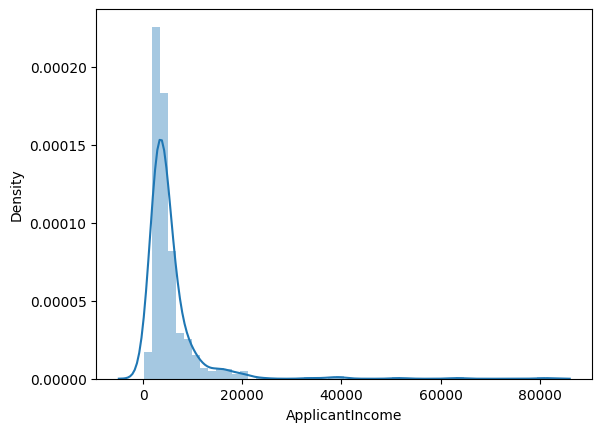

In [119]:
sns.distplot(df['ApplicantIncome'])

In [120]:
df['ApplicantIncome'] = np.log1p(df['ApplicantIncome'])

/tmp/ipykernel_10249/2349853404.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ApplicantIncome'])


<Axes: xlabel='ApplicantIncome', ylabel='Density'>

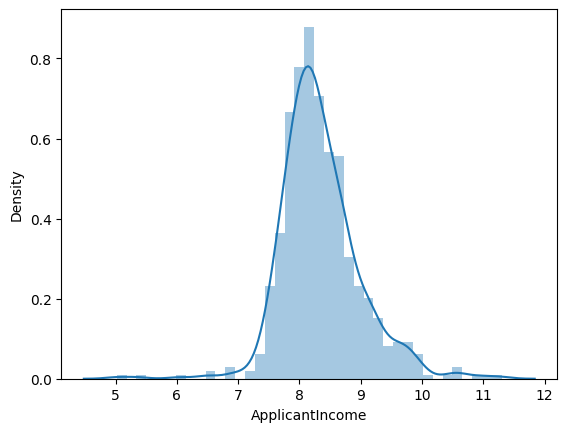

In [121]:
sns.distplot(df['ApplicantIncome'])

/tmp/ipykernel_10249/2149142820.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CoapplicantIncome'])


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

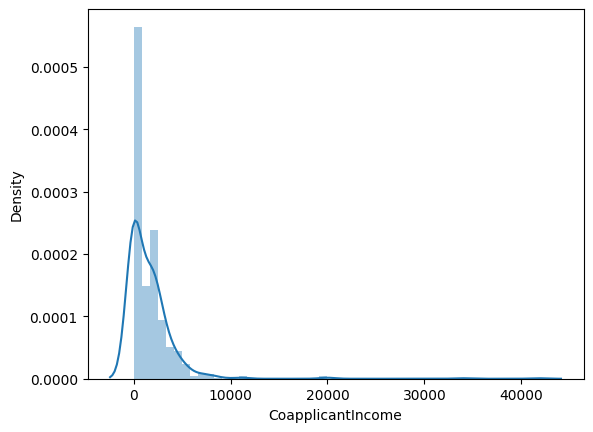

In [122]:
sns.distplot(df['CoapplicantIncome'])

In [123]:
df['CoapplicantIncome'] = np.log1p(df['CoapplicantIncome'])

/tmp/ipykernel_10249/2149142820.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CoapplicantIncome'])


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

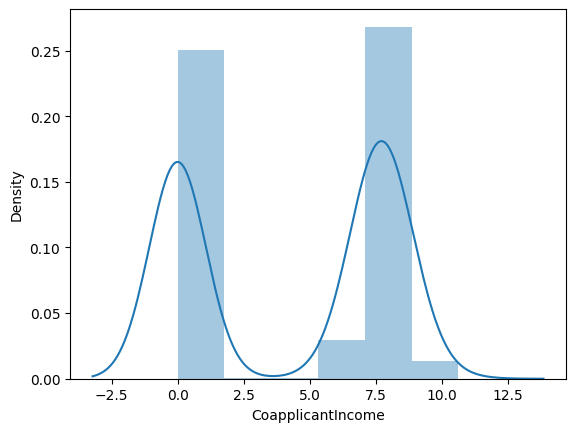

In [124]:
sns.distplot(df['CoapplicantIncome'])

/tmp/ipykernel_10249/413488336.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['LoanAmount'])


<Axes: xlabel='LoanAmount', ylabel='Density'>

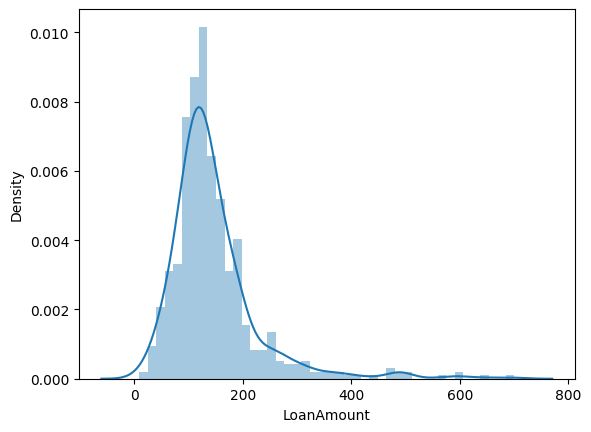

In [125]:
sns.distplot(df['LoanAmount'])

In [126]:
df['LoanAmount'] = np.log1p(df['LoanAmount'])

/tmp/ipykernel_10249/413488336.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['LoanAmount'])


<Axes: xlabel='LoanAmount', ylabel='Density'>

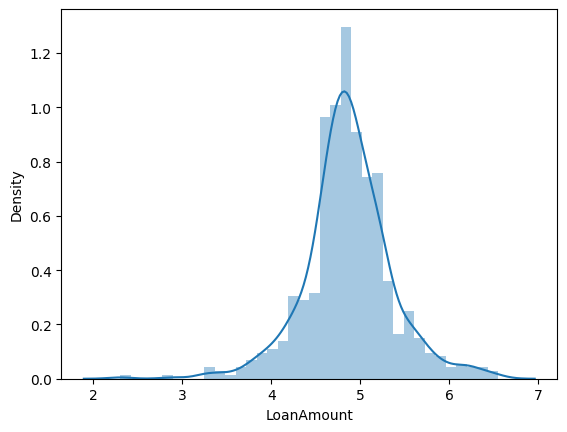

In [127]:
sns.distplot(df['LoanAmount'])

In [128]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant
0,LP001002,Male,No,0,Graduate,No,8.674197,0.000000,4.955827,360.0,1.0,Urban,Y,5849.0,2,0.024107,0
1,LP001003,Male,Yes,1,Graduate,No,8.430327,7.319202,4.859812,360.0,1.0,Rural,N,6091.0,2,0.021015,1
2,LP001005,Male,Yes,0,Graduate,Yes,8.006701,0.000000,4.204693,360.0,1.0,Urban,Y,3000.0,0,0.022000,0
3,LP001006,Male,Yes,0,Not Graduate,No,7.857094,7.765993,4.795791,360.0,1.0,Urban,Y,4941.0,1,0.024287,1
4,LP001008,Male,No,0,Graduate,No,8.699681,0.000000,4.955827,360.0,1.0,Urban,Y,6000.0,2,0.023500,0


In [129]:
df.drop('Loan_ID',axis=1,inplace=True)

In [130]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant
0,Male,No,0,Graduate,No,8.674197,0.000000,4.955827,360.0,1.0,Urban,Y,5849.0,2,0.024107,0
1,Male,Yes,1,Graduate,No,8.430327,7.319202,4.859812,360.0,1.0,Rural,N,6091.0,2,0.021015,1
2,Male,Yes,0,Graduate,Yes,8.006701,0.000000,4.204693,360.0,1.0,Urban,Y,3000.0,0,0.022000,0
3,Male,Yes,0,Not Graduate,No,7.857094,7.765993,4.795791,360.0,1.0,Urban,Y,4941.0,1,0.024287,1
4,Male,No,0,Graduate,No,8.699681,0.000000,4.955827,360.0,1.0,Urban,Y,6000.0,2,0.023500,0


In [131]:
df.dtypes

,0
Gender,object
Married,object
Dependents,int64
Education,object
Self_Employed,object
ApplicantIncome,float64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64


In [132]:
cat_cols = [column for column in df.columns if df[column].dtypes == 'O']

In [133]:
cat_cols

['Gender',
 'Married',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [134]:
df[cat_cols]

,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
0,Male,No,Graduate,No,Urban,Y
1,Male,Yes,Graduate,No,Rural,N
2,Male,Yes,Graduate,Yes,Urban,Y
3,Male,Yes,Not Graduate,No,Urban,Y
4,Male,No,Graduate,No,Urban,Y
...,...,...,...,...,...,...
609,Female,No,Graduate,No,Rural,Y
610,Male,Yes,Graduate,No,Rural,Y
611,Male,Yes,Graduate,No,Urban,Y
612,Male,Yes,Graduate,No,Urban,Y


In [135]:
from sklearn.preprocessing import OneHotEncoder

In [136]:
ohe = OneHotEncoder(drop="first", sparse_output=False)

In [137]:
encoded_data = ohe.fit_transform(df[cat_cols])

In [138]:
encoded_data

array([[1., 0., 0., ..., 0., 1., 1.],
       [1., 1., 0., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 1., 1.],
       ...,
       [1., 1., 0., ..., 0., 1., 1.],
       [1., 1., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [139]:
encoded_df = pd.DataFrame(encoded_data,columns = ohe.get_feature_names_out(cat_cols), index=df.index)

In [140]:
encoded_df

,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,1.0,0.0,1.0,1.0
3,1.0,1.0,1.0,0.0,0.0,1.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...
609,0.0,0.0,0.0,0.0,0.0,0.0,1.0
610,1.0,1.0,0.0,0.0,0.0,0.0,1.0
611,1.0,1.0,0.0,0.0,0.0,1.0,1.0
612,1.0,1.0,0.0,0.0,0.0,1.0,1.0


In [141]:
df.head(1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant
0,Male,No,0,Graduate,No,8.674197,0.0,4.955827,360.0,1.0,Urban,Y,5849.0,2,0.024107,0


In [142]:
df = pd.concat([df,encoded_df],axis=1)

In [143]:
df.head(1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,...,IncomeBand,LoanIncomeRatio,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,Male,No,0,Graduate,No,8.674197,0.0,4.955827,360.0,1.0,...,2,0.024107,0,1.0,0.0,0.0,0.0,0.0,1.0,1.0


In [144]:
df.drop(columns=cat_cols,axis=1,inplace=True)

In [145]:
df.head(10)

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,0,8.674197,0.000000,4.955827,360.0,1.0,5849.0,2,0.024107,0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1,8.430327,7.319202,4.859812,360.0,1.0,6091.0,2,0.021015,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0,8.006701,0.000000,4.204693,360.0,1.0,3000.0,0,0.022000,0,1.0,1.0,0.0,1.0,0.0,1.0,1.0
3,0,7.857094,7.765993,4.795791,360.0,1.0,4941.0,1,0.024287,1,1.0,1.0,1.0,0.0,0.0,1.0,1.0
4,0,8.699681,0.000000,4.955827,360.0,1.0,6000.0,2,0.023500,0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
5,2,8.597482,8.342125,5.590987,360.0,1.0,9613.0,3,0.027775,1,1.0,1.0,0.0,1.0,0.0,1.0,1.0
6,0,7.755339,7.324490,4.564348,360.0,1.0,3849.0,0,0.024682,1,1.0,1.0,1.0,0.0,0.0,1.0,1.0
7,3,8.018625,7.826044,5.068904,360.0,0.0,5540.0,2,0.028520,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0
8,2,8.295798,7.331060,5.129899,360.0,1.0,5532.0,2,0.030369,1,1.0,1.0,0.0,0.0,0.0,1.0,1.0
9,1,9.460476,9.302828,5.857933,360.0,1.0,23809.0,3,0.014658,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [146]:
from sklearn.preprocessing import StandardScaler

In [147]:
scaling_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','TotalIncome','LoanIncomeRatio']

In [148]:
scaler = StandardScaler()

In [149]:
df[scaling_cols] = scaler.fit_transform(df[scaling_cols])

In [150]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,0,0.516186,-1.107783,0.180177,0.273231,1.0,-0.182184,2,0.034587,0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1,0.137806,0.782158,-0.014813,0.273231,1.0,-0.144684,2,-0.336243,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0,-0.519479,-1.107783,-1.345255,0.273231,1.0,-0.623656,0,-0.218066,0,1.0,1.0,0.0,1.0,0.0,1.0,1.0
3,0,-0.751605,0.897526,-0.144831,0.273231,1.0,-0.322885,1,0.056162,1,1.0,1.0,1.0,0.0,0.0,1.0,1.0
4,0,0.555727,-1.107783,0.180177,0.273231,1.0,-0.158785,2,-0.038172,0,1.0,0.0,0.0,0.0,0.0,1.0,1.0


# Feature Selection

In [151]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,0,0.516186,-1.107783,0.180177,0.273231,1.0,-0.182184,2,0.034587,0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1,0.137806,0.782158,-0.014813,0.273231,1.0,-0.144684,2,-0.336243,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0,-0.519479,-1.107783,-1.345255,0.273231,1.0,-0.623656,0,-0.218066,0,1.0,1.0,0.0,1.0,0.0,1.0,1.0
3,0,-0.751605,0.897526,-0.144831,0.273231,1.0,-0.322885,1,0.056162,1,1.0,1.0,1.0,0.0,0.0,1.0,1.0
4,0,0.555727,-1.107783,0.180177,0.273231,1.0,-0.158785,2,-0.038172,0,1.0,0.0,0.0,0.0,0.0,1.0,1.0


In [152]:
X = df.drop("Loan_Status_Y",axis=1)
y =df["Loan_Status_Y"]

In [153]:
X

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,0.516186,-1.107783,0.180177,0.273231,1.0,-0.182184,2,0.034587,0,1.0,0.0,0.0,0.0,0.0,1.0
1,1,0.137806,0.782158,-0.014813,0.273231,1.0,-0.144684,2,-0.336243,1,1.0,1.0,0.0,0.0,0.0,0.0
2,0,-0.519479,-1.107783,-1.345255,0.273231,1.0,-0.623656,0,-0.218066,0,1.0,1.0,0.0,1.0,0.0,1.0
3,0,-0.751605,0.897526,-0.144831,0.273231,1.0,-0.322885,1,0.056162,1,1.0,1.0,1.0,0.0,0.0,1.0
4,0,0.555727,-1.107783,0.180177,0.273231,1.0,-0.158785,2,-0.038172,0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,-0.572062,-1.107783,-1.199088,0.273231,1.0,-0.639152,0,0.079689,0,0.0,0.0,0.0,0.0,0.0,0.0
610,3,-0.032679,-1.107783,-2.342641,-2.522836,1.0,-0.452274,0,-1.688178,0,1.0,1.0,0.0,0.0,0.0,0.0
611,1,1.015921,0.308483,1.361123,0.273231,1.0,0.199475,3,0.793887,1,1.0,1.0,0.0,0.0,0.0,1.0
612,2,0.918972,-1.107783,0.750060,0.273231,1.0,0.086512,3,0.100996,0,1.0,1.0,0.0,0.0,0.0,1.0


In [154]:
y

,Loan_Status_Y
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
609,1.0
610,1.0
611,1.0
612,1.0


In [155]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(mutual_info_classif,k=8)

In [156]:
X_new = selector.fit_transform(X,y)

In [157]:
X.columns[selector.get_support()]

Index(['Dependents', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History',
       'IncomeBand', 'HasCoapplicant', 'Married_Yes', 'Self_Employed_Yes'],
      dtype='object')